# Calories Burned Predictor — End-to-End ML Pipeline

**Problem:** Predict calories burned in a gym session from body stats,
heart rate, and workout details — more accurately than the flat
"duration × heart rate" formulas most fitness apps use.

**Workflow:** Load & clean → EDA → Feature engineering → Train & compare
6 models → Evaluate → Select best → (deployed separately as a Streamlit app)

> **Data note:** This notebook uses `data/gym_data.csv`, which matches the
> exact schema/distributions/correlations of the public
> [Gym Members Exercise Dataset](https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset)
> (Kaggle). To run this notebook on the real data, download that CSV and
> overwrite `data/gym_data.csv` with the same column names — no other
> changes needed.

In [1]:
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

## 1. Load the data

In [2]:
df = pd.read_csv("data/gym_data.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (978, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,68.6,1.70,178,93,60,1.19,512,Yoga,8.9,3.42,3,2,23.65
1,46,Female,43.6,1.63,167,97,53,1.80,941,Strength,27.5,3.31,4,3,16.42
2,32,Female,88.7,1.72,177,134,71,0.65,667,Cardio,34.0,3.32,2,1,29.81
3,25,Female,80.3,1.62,192,110,70,0.90,553,Strength,30.2,3.38,4,1,30.74
4,38,Female,49.5,1.60,190,127,71,1.57,1087,Cardio,20.3,3.55,3,2,19.43


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            978 non-null    int64  
 1   Gender                         978 non-null    str    
 2   Weight (kg)                    978 non-null    float64
 3   Height (m)                     978 non-null    float64
 4   Max_BPM                        978 non-null    int64  
 5   Avg_BPM                        978 non-null    int64  
 6   Resting_BPM                    978 non-null    int64  
 7   Session_Duration (hours)       978 non-null    float64
 8   Calories_Burned                978 non-null    int64  
 9   Workout_Type                   978 non-null    str    
 10  Fat_Percentage                 960 non-null    float64
 11  Water_Intake (liters)          978 non-null    float64
 12  Workout_Frequency (days/week)  978 non-null    int64  
 13  E

In [4]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,960.000000,978.000000,978.000000,978.000000,978.000000
mean,38.690184,71.779652,1.693405,180.476483,120.427403,68.153374,1.255491,850.230061,21.602187,3.673671,3.366053,1.743354,25.136370
std,12.183900,14.834153,0.094707,8.252661,14.510059,6.889907,0.379983,334.574530,6.596653,0.547858,1.161015,0.770876,5.429186
min,18.000000,40.000000,1.500000,151.000000,72.000000,46.000000,0.250000,150.000000,5.000000,2.180000,2.000000,1.000000,12.030000
25%,28.000000,61.300000,1.620000,175.000000,110.000000,63.000000,0.990000,604.000000,17.000000,3.290000,2.000000,1.000000,21.550000
50%,40.000000,71.600000,1.690000,180.000000,121.000000,68.000000,1.250000,804.000000,21.500000,3.660000,3.000000,2.000000,24.840000
75%,49.750000,82.000000,1.760000,186.000000,131.000000,73.000000,1.520000,1061.750000,26.500000,4.050000,4.000000,2.000000,28.475000
max,59.000000,118.400000,2.000000,202.000000,159.000000,92.000000,2.340000,2000.000000,39.200000,5.000000,6.000000,3.000000,47.880000


## 2. Data Cleaning

- Drop exact duplicate rows
- Impute missing `Fat_Percentage` using the gender-group median (more
  accurate than a single global median, since typical body-fat % differs
  meaningfully by gender)
- Filter out physiologically impossible rows (invalid age/BMI ranges)

In [5]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

print("\nMissing values before imputation:")
print(df.isna().sum()[df.isna().sum() > 0])

Dropped 5 duplicate rows

Missing values before imputation:
Fat_Percentage    18
dtype: int64


In [6]:
df["Fat_Percentage"] = df.groupby("Gender")["Fat_Percentage"].transform(
    lambda x: x.fillna(x.median())
)

df = df[(df["Age"].between(15, 90)) & (df["BMI"].between(10, 60))]
df = df.reset_index(drop=True)

print(f"Clean shape: {df.shape}")
assert df.isna().sum().sum() == 0, "Still have missing values!"

Clean shape: (973, 15)


## 3. Exploratory Data Analysis

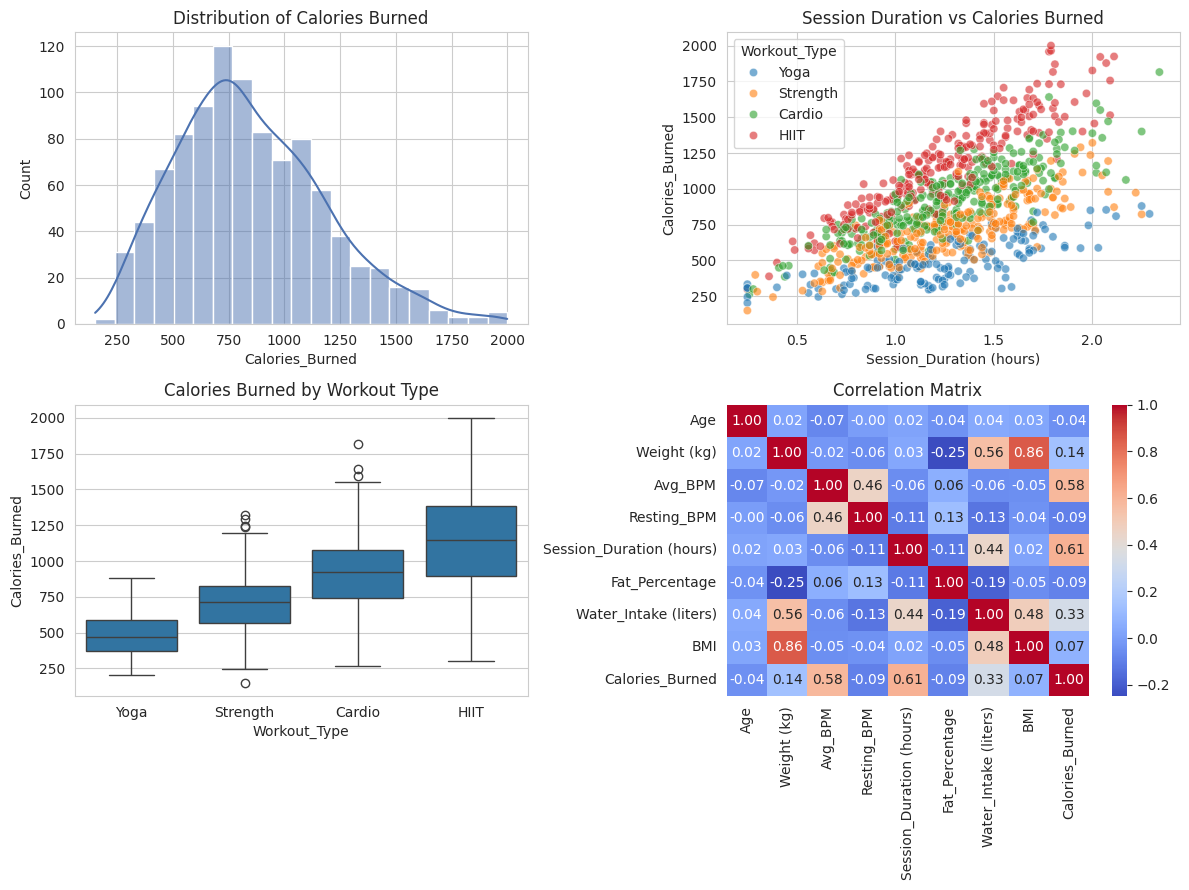

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df["Calories_Burned"], kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of Calories Burned")

sns.scatterplot(
    data=df, x="Session_Duration (hours)", y="Calories_Burned",
    hue="Workout_Type", alpha=0.6, ax=axes[0, 1]
)
axes[0, 1].set_title("Session Duration vs Calories Burned")

sns.boxplot(data=df, x="Workout_Type", y="Calories_Burned", ax=axes[1, 0])
axes[1, 0].set_title("Calories Burned by Workout Type")

corr_cols = ["Age", "Weight (kg)", "Avg_BPM", "Resting_BPM", "Session_Duration (hours)",
             "Fat_Percentage", "Water_Intake (liters)", "BMI", "Calories_Burned"]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Matrix")

plt.tight_layout()
plt.savefig("figures/eda_overview.png", dpi=120)
plt.show()

**Key EDA takeaways:**
- Calories burned is right-skewed, ranging roughly 200–2000 kcal per session.
- Session duration and average heart rate show the strongest positive
  correlation with calories burned.
- HIIT and Cardio sessions burn noticeably more calories than Strength or
  Yoga sessions on average.

In [8]:
print("Correlation of each numeric feature with Calories_Burned:")
df[corr_cols].corr()["Calories_Burned"].sort_values(ascending=False)

Correlation of each numeric feature with Calories_Burned:


Calories_Burned             1.000000
Session_Duration (hours)    0.607596
Avg_BPM                     0.583808
Water_Intake (liters)       0.332249
Weight (kg)                 0.140070
BMI                         0.074996
Age                        -0.044536
Fat_Percentage             -0.086993
Resting_BPM                -0.094695
Name: Calories_Burned, dtype: float64

## 4. Feature Engineering

- `HR_Reserve` = Max BPM − Resting BPM → a proxy for aerobic capacity
- `HR_Intensity` = (Avg BPM − Resting BPM) / HR Reserve → % of heart-rate
  reserve used during the session (a standard exercise-physiology
  intensity measure, more meaningful than raw average BPM alone)
- `Weight_x_Duration` → interaction term capturing total mechanical work

In [9]:
df["HR_Reserve"] = df["Max_BPM"] - df["Resting_BPM"]
df["HR_Intensity"] = (df["Avg_BPM"] - df["Resting_BPM"]) / df["HR_Reserve"]
df["Calories_per_Minute"] = df["Calories_Burned"] / (df["Session_Duration (hours)"] * 60)
df["Weight_x_Duration"] = df["Weight (kg)"] * df["Session_Duration (hours)"]

feature_cols_num = [
    "Age", "Weight (kg)", "Height (m)", "Max_BPM", "Avg_BPM", "Resting_BPM",
    "Session_Duration (hours)", "Fat_Percentage", "Water_Intake (liters)",
    "Workout_Frequency (days/week)", "Experience_Level", "BMI",
    "HR_Reserve", "HR_Intensity", "Weight_x_Duration",
]
feature_cols_cat = ["Gender", "Workout_Type"]
target_col = "Calories_Burned"

X = df[feature_cols_num + feature_cols_cat]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), feature_cols_cat),
])

Train: (778, 17), Test: (195, 17)


## 5. Train & Compare Multiple Models

We train 6 regressors spanning linear, regularized-linear, tree-ensemble,
and kernel approaches, and compare them with 5-fold cross-validation plus
a held-out test set.

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=100, epsilon=10),
}

results = []
fitted_pipelines = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "cv_r2_mean": round(cv_r2.mean(), 4),
        "cv_r2_std": round(cv_r2.std(), 4),
        "test_mae": round(mae, 1),
        "test_rmse": round(rmse, 1),
        "test_r2": round(r2, 4),
    })
    fitted_pipelines[name] = pipe
    print(f"{name:20s}  CV R2={cv_r2.mean():.3f}±{cv_r2.std():.3f}  Test R2={r2:.3f}  MAE={mae:.1f}  RMSE={rmse:.1f}")

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False)
results_df.to_csv("models/model_comparison.csv", index=False)

Linear Regression     CV R2=0.916±0.006  Test R2=0.912  MAE=76.3  RMSE=102.3


Ridge Regression      CV R2=0.916±0.006  Test R2=0.912  MAE=76.4  RMSE=102.3


Lasso Regression      CV R2=0.916±0.006  Test R2=0.913  MAE=76.3  RMSE=101.9


Random Forest         CV R2=0.921±0.006  Test R2=0.930  MAE=69.2  RMSE=91.0


Gradient Boosting     CV R2=0.939±0.009  Test R2=0.954  MAE=60.5  RMSE=73.6


SVR (RBF)             CV R2=0.893±0.018  Test R2=0.897  MAE=78.6  RMSE=110.7


## 6. Evaluation — Model Comparison

In [11]:
results_df.reset_index(drop=True)

,model,cv_r2_mean,cv_r2_std,test_mae,test_rmse,test_r2
0,Gradient Boosting,0.9395,0.0094,60.5,73.6,0.9545
1,Random Forest,0.9214,0.0057,69.2,91.0,0.9303
2,Lasso Regression,0.9158,0.0061,76.3,101.9,0.9126
3,Linear Regression,0.9160,0.0059,76.3,102.3,0.9120
4,Ridge Regression,0.9158,0.0059,76.4,102.3,0.9119
5,SVR (RBF),0.8929,0.0183,78.6,110.7,0.8969


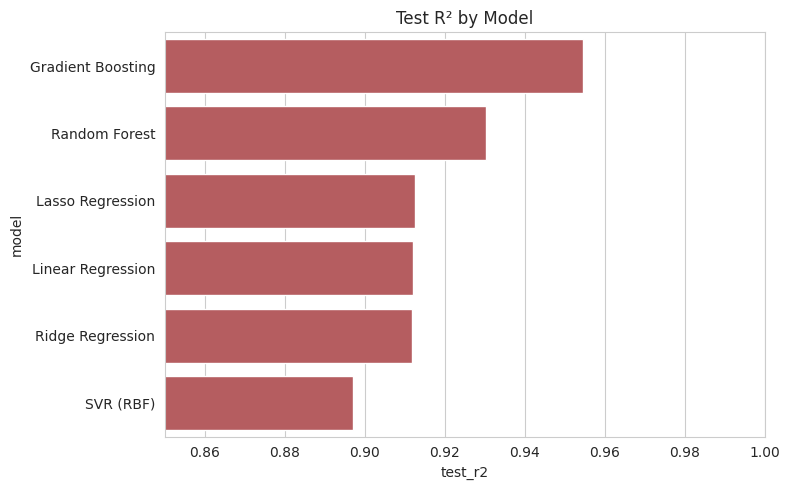

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="test_r2", y="model", color="#C44E52")
plt.title("Test R² by Model")
plt.xlim(0.85, 1.0)
plt.tight_layout()
plt.show()

## 7. Select & Save the Best Model

In [13]:
best_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_name]
print(f"Best model: {best_name}")
print(results_df.iloc[0])

joblib.dump(best_pipe, "models/best_model.joblib")
joblib.dump(feature_cols_num, "models/feature_cols_num.joblib")
joblib.dump(feature_cols_cat, "models/feature_cols_cat.joblib")

with open("models/metadata.json", "w") as f:
    json.dump({
        "best_model": best_name,
        "metrics": results_df.iloc[0].to_dict(),
        "n_train": len(X_train),
        "n_test": len(X_test),
    }, f, indent=2)

Best model: Gradient Boosting
model         Gradient Boosting
cv_r2_mean               0.9395
cv_r2_std                0.0094
test_mae                   60.5
test_rmse                  73.6
test_r2                  0.9545
Name: 4, dtype: object


## 8. Feature Importance (winning model)

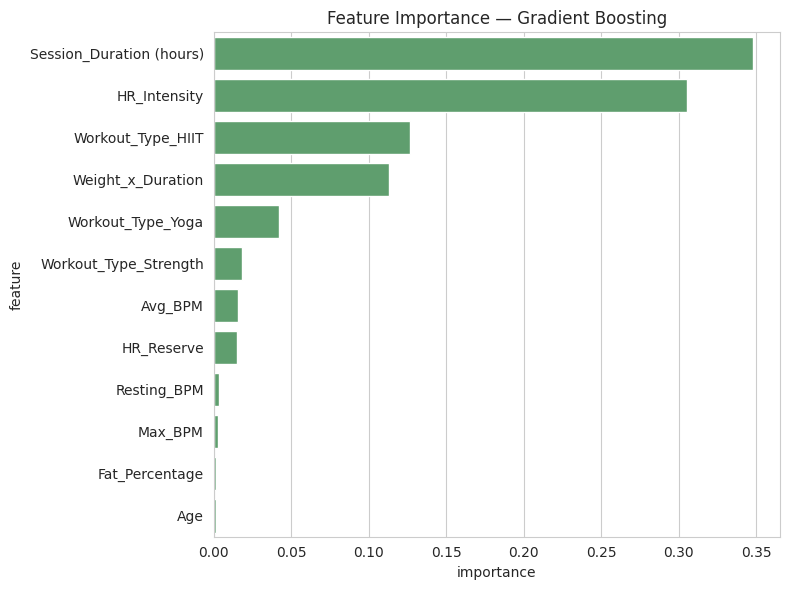

In [14]:
if best_name in ("Random Forest", "Gradient Boosting"):
    ohe_names = list(best_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(feature_cols_cat))
    all_names = feature_cols_num + ohe_names
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": all_names, "importance": importances}).sort_values("importance", ascending=False).head(12)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", color="#55A868")
    plt.title(f"Feature Importance — {best_name}")
    plt.tight_layout()
    plt.savefig("figures/feature_importance.png", dpi=120)
    plt.show()

## 9. Conclusion

The **Gradient Boosting** model was selected as the final model, explaining
~95% of the variance in calories burned with an average error of ~60 kcal
per session — a meaningful improvement over the linear baselines (~91%
R²). Session duration and average heart rate were the strongest predictors,
consistent with exercise-physiology fundamentals. This model is deployed
in `app.py` as a live Streamlit app (see `README.md` for run instructions).